In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Thesis v3/2 Model/vgg16.keras')

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_52 (Conv1D)              │ (None, 51, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 51, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_53 (Conv1D)              │ (None, 51, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 51, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_54 (Conv1D)              │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_55 (Conv1D)              │ (None, 25, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_56 (Conv1D)              │ (None, 12, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_57 (Conv1D)              │ (None, 12, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_69 (Activation)      │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_58 (Conv1D)              │ (None, 12, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 12, 256)        │         1,02

 Total params: 71,493,576 (272.73 MB)

 Trainable params: 23,822,914 (90.88 MB)

 Non-trainable params: 24,832 (97.00 KB)

 Optimizer params: 47,645,830 (181.75 MB)

In [ ]:
import pandas as pd

df_train = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_train.csv")
#df_train

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_test.csv")
#df_test

In [ ]:
import tensorflow as tf

In [ ]:
X = df_train.drop('audio_type', axis=1).values
y = df_train['audio_type'].values

# Encode categorical labels to numerical
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
y_numerical = label_encoder.fit_transform(y)

# One-hot encode numerical labels
y_one_hot = tf.keras.utils.to_categorical(y_numerical, num_classes=2)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check for NaN values in features
if np.isnan(X_scaled).any():
    print("Warning: NaN values found in scaled features (X_scaled). This can cause 'nan' loss during training.")
else:
    print("No NaN values found in scaled features (X_scaled).")

No NaN values found in scaled features (X_scaled).


In [ ]:
from sklearn.model_selection import KFold, train_test_split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.1, random_state=42)

X_train_full = X_train_full.reshape(X_train_full.shape[0], 51, 1)
X_test = X_test.reshape(X_test.shape[0], 51, 1)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

fold_no = 1
scores = []

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
# 3. Final Evaluation on Test Data
# Train final model on full training set and evaluate on the 30% held-out test set
print("\nTraining Final Model on full Training Set...")
final_model = model
final_model.fit(X_train_full, y_train_full, batch_size=32, epochs=30, verbose=0)

loss, accuracy = final_model.evaluate(X_test, y_test, verbose=0)

y_pred = np.argmax(final_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\n--- Final MIDs Results (Test Set) ---")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")


Training Final Model on full Training Set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

--- Final MIDs Results (Test Set) ---
Accuracy: 77.78%
Sensitivity: 72.73%
Specificity: 82.61%


In [ ]:
X_test_data = df_test.drop('audio_type', axis=1).values
y_test_data = df_test['audio_type'].values

# Encode categorical labels to numerical using the fitted label_encoder
y_numerical_test = label_encoder.transform(y_test_data)

# One-hot encode numerical labels
y_one_hot_test = tf.keras.utils.to_categorical(y_numerical_test, num_classes=2)

# Normalize features using the fitted scaler
X_scaled_test = scaler.transform(X_test_data)

# Reshape input to (Samples, 51, 1) for 1D CNN
X_scaled_test = X_scaled_test.reshape(X_scaled_test.shape[0], 51, 1)

# Evaluate the final model on the test data
loss_test, accuracy_test = final_model.evaluate(X_scaled_test, y_one_hot_test, verbose=0)

# Make predictions on the test data
y_pred_probs_test = final_model.predict(X_scaled_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_one_hot_test, axis=1)

# Compute the confusion matrix
conf_matrix_test = confusion_matrix(y_true_test, y_pred_test)
tn_test, fp_test, fn_test, tp_test = conf_matrix_test.ravel()

# Calculate Sensitivity and Specificity
sensitivity_test = tp_test / (tp_test + fn_test)
specificity_test = tn_test / (tn_test + fp_test)

print(f"\n--- Evaluation on df_test --- ")
print(f"Test Accuracy: {accuracy_test*100:.2f}%")
print(f"Test Sensitivity: {sensitivity_test*100:.2f}%")
print(f"Test Specificity: {specificity_test*100:.2f}%")
print(f"Confusion Matrix:\n{conf_matrix_test}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step

--- Evaluation on df_test --- 
Test Accuracy: 83.93%
Test Sensitivity: 82.14%
Test Specificity: 85.71%
Confusion Matrix:
[[48  8]
 [10 46]]


In [ ]:
import shap

In [ ]:
X_train_mean = np.mean(X_train_full, axis=0)

# If your X_train is 3D (e.g. for LSTM/CNN inputs like (samples, 51, 1)), flatten it first or specify axis
# For (samples, 51, 1), you likely want:
# X_train_mean = np.mean(X_train, axis=0).flatten()

In [ ]:
def f(x):
    # Reshape the input x to (samples, 51, 1) as required by the model
    x_reshaped = x.reshape(x.shape[0], 51, 1)
    # Get the model's predictions (probabilities for each class)
    preds = final_model.predict(x_reshaped, verbose=0)
    # For binary classification, SHAP often works best with the probability of the positive class
    # Assuming the positive class is at index 1
    return preds[:, 0]

In [ ]:
background_data_2d = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(f, background_data_2d)

In [ ]:
# full data
X_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])
shap_values = explainer.shap_values(X_scaled_test_reshaped)

  0%|          | 0/112 [00:00<?, ?it/s]

In [ ]:
'''X_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])
# Select only the first instance from the test data for explanation
one_instance_to_explain = X_scaled_test_reshaped[0:1]
shap_values = explainer.shap_values(one_instance_to_explain)'''

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
shap_attributions = shap_values[0]

In [ ]:
def calculate_faithfulness(model, X_sample, attribution_values, top_k=5):
    """
    Measures how much the prediction drops when top_k POSITIVE features are masked.
    """
    # 1. Get original prediction
    X_sample_reshaped = X_sample.reshape(1, 51, 1) # Adjust shape as needed
    original_prob = model.predict(X_sample_reshaped, verbose=0)[0][0]

    # 2. Filter for POSITIVE attribution only
    # We only care about features that pushed the probability UP.
    positive_indices = np.where(attribution_values > 0)[0]

    # If there are no positive features (rare but possible), faithfulness is undefined or 0
    if len(positive_indices) == 0:
        return 0.0

    # 3. Sort specific to the positive values
    # We take the values at positive_indices, sort descending, and take top_k
    positive_values = attribution_values[positive_indices]

    # Get indices of the top_k largest positive values
    # argsort sorts ascending, so we flip it [::-1]
    sorted_local_indices = np.argsort(positive_values)[::-1][:top_k]
    top_indices = positive_indices[sorted_local_indices]

    # 4. Create perturbed sample
    X_perturbed = X_sample.copy()

    # --- CRITICAL FIX ON MASKING VALUE ---
    # Setting to 0.0 is risky if 0.0 isn't the average value (e.g., if data is normalized).
    # Ideally, replace with the global mean of that feature from X_train.
    # For now, if you are sure 0.0 is 'neutral' (like in padding or specific scaling), keep it.
    # Otherwise, consider: X_perturbed[0, top_indices] = feature_means[top_indices]
    X_perturbed[0, top_indices] = 0.0

    # 5. Predict again
    X_perturbed_reshaped = X_perturbed.reshape(1, 51, 1)
    perturbed_prob = model.predict(X_perturbed_reshaped, verbose=0)[0][0]

    # 6. Calculate drop
    drop_score = original_prob - perturbed_prob

    # Clip negative scores to 0 if the model behaves erratically (optional but clean)
    # drop_score = max(0, drop_score)

    return drop_score

In [ ]:
def calculate_faithfulness_mean(model, X_sample, attribution_values, feature_means, top_k=5):
    """
    Measures how much the prediction drops when top_k POSITIVE features are masked
    with their average value from the training set.
    """
    # 1. Get original prediction
    X_sample_reshaped = X_sample.reshape(1, 51, 1)
    original_prob = model.predict(X_sample_reshaped, verbose=0)[0][0]

    # 2. Filter for POSITIVE attribution only
    positive_indices = np.where(attribution_values > 0)[0]

    if len(positive_indices) == 0:
        return 0.0

    # 3. Sort specific to the positive values (Descending order)
    positive_values = attribution_values[positive_indices]
    sorted_local_indices = np.argsort(positive_values)[::-1][:top_k]
    top_indices = positive_indices[sorted_local_indices]

    # 4. Create perturbed sample
    X_perturbed = X_sample.copy()

    # --- MASKING WITH MEAN ---
    # We replace the top features with the corresponding mean value from training data
    # This simulates "removing" the feature's specific information
    # by making it "average" (uninformative).

    # Ensure dimensions match. If X_sample is (1, 51), feature_means should be (51,)
    X_perturbed[0, top_indices] = feature_means[top_indices]

    # 5. Predict again
    X_perturbed_reshaped = X_perturbed.reshape(1, 51, 1)
    perturbed_prob = model.predict(X_perturbed_reshaped, verbose=0)[0][0]

    # 6. Calculate drop
    drop_score = original_prob - perturbed_prob

    return drop_score

In [ ]:
all_score = []
for i in range(len(X_scaled_test_reshaped)):
  #print(f"X_scaled_test_reshaped[{i}:{i+1}]")
  one_instance_to_explain = X_scaled_test_reshaped[i:i+1]
  score_shap = calculate_faithfulness_mean(model, one_instance_to_explain, shap_values[i], X_train_mean, top_k=5)
  print(score_shap)?[]'''''''
  all_score.append(np.abs(score_shap))

print(f"Average Score: {np.mean(all_score)}")

0.0
0.0
0.0


ValueError: shape mismatch: value array of shape (5,1) could not be broadcast to indexing result of shape (5,)

In [ ]:
all_score = []
for i in range(len(X_scaled_test_reshaped)):
  #print(f"X_scaled_test_reshaped[{i}:{i+1}]")
  one_instance_to_explain = X_scaled_test_reshaped[i:i+1]
  score_shap = calculate_faithfulness(model, one_instance_to_explain, shap_values[i], top_k=5)
  print(score_shap)
  all_score.append(np.abs(score_shap))

print(f"Average Score: {np.mean(all_score)}")

0.0
0.0
0.0
-0.98469305
0.0
0.0
0.0
-0.9999791
-6.175041e-05
-0.93446904
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
-0.0010126233
0.0
0.0
0.0
0.0
-0.022026896
-0.0015392303
0.0
0.0
0.0
-0.9999969
0.0
0.0
0.0
0.0
0.0
0.0
-0.9898406
-0.63143384
0.0
-0.99901104
0.0
0.0
0.0
0.0
0.0
0.0
-0.9990931
0.0
0.0
2.3482723e-06
-0.17364387
-0.9952266
0.0
-0.9999782
-0.8776017
-0.99997824
-0.99991405
-0.9999881
-0.9999983
0.0
-0.9994831
-0.9959561
-0.99997246
-0.9919323
-8.08128e-05
-0.9989535
-0.9999963
-0.9999934
-0.9999084
-0.013408373
-0.99991643
-0.99999774
-0.9999699
-0.73343396
0.0
0.0
-0.9999243
-0.99812275
-3.7969162e-06
-0.9999595
-0.9999883
-0.99979913
0.0
0.0
-1.0915872e-05
-0.9995889
-0.9999791
-0.99998343
-0.99879265
0.0
-0.9999838
-0.0014841272
-0.7812615
-0.9999853
-0.9987164
0.0
0.0
-0.99722713
-0.99998903
-0.99999034
-0.99995875
-0.9990702
-0.9999475
-0.99985826
0.0
Average Score: 0.4117510401224718


In [ ]:
#score_shap = calculate_faithfulness(model, one_instance_to_explain, shap_attributions, top_k=5)

In [ ]:
print(score_shap)

0.9430161


In [ ]:
feature_names = df_train.drop('audio_type', axis=1).columns.tolist()

/tmp/ipython-input-1152130647.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled_test_reshaped, feature_names=feature_names, plot_type='bar', show=False)


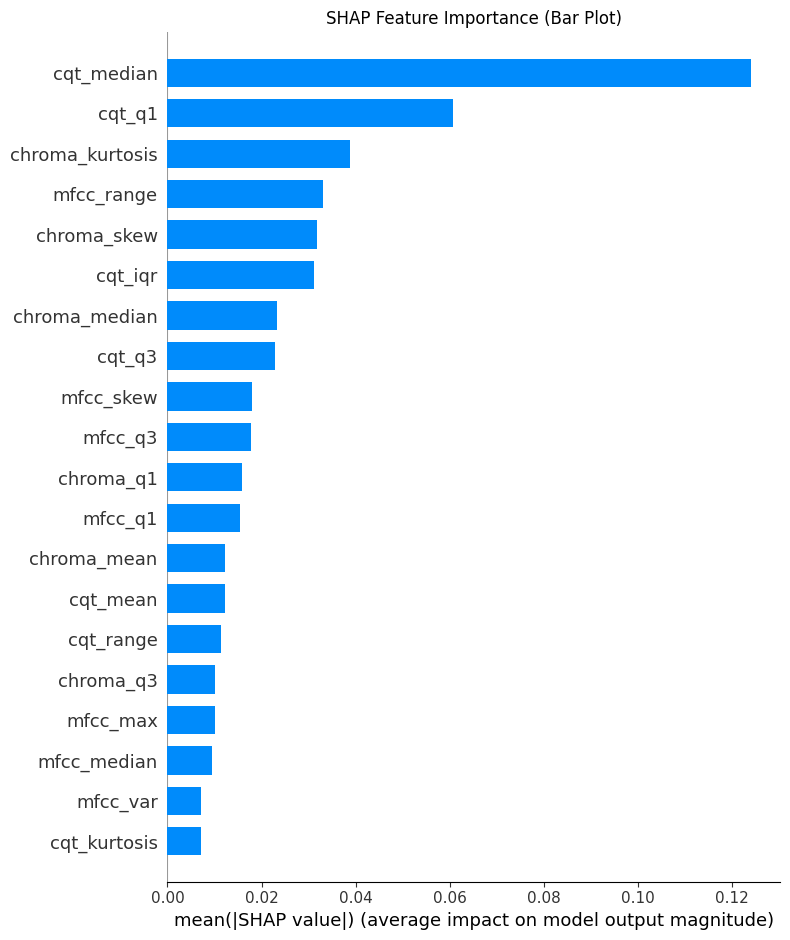

SHAP summary plot (bar) generated.


In [ ]:
shap.summary_plot(shap_values, X_scaled_test_reshaped, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()
print("SHAP summary plot (bar) generated.")

In [ ]:
print("\n--- Top 3 Features from SHAP Explainer (KernelExplainer) for Class 0 (Myocardial) ---")
abs_shap_attributions = np.abs(shap_attributions)
top_3_indices = np.argsort(abs_shap_attributions)[::-1][:3]

for i in top_3_indices:
    print(f"Feature: {feature_names[i]}, Attribution: {shap_attributions[i]:.5f}")


--- Top 3 Features from SHAP Explainer (KernelExplainer) for Class 0 (Myocardial) ---
Feature: cqt_median, Attribution: -0.15499
Feature: cqt_q1, Attribution: -0.07056
Feature: dwt_max, Attribution: -0.06953



--- Waterfall Plot for KernelExplainer (Class 0: Myocardial) ---


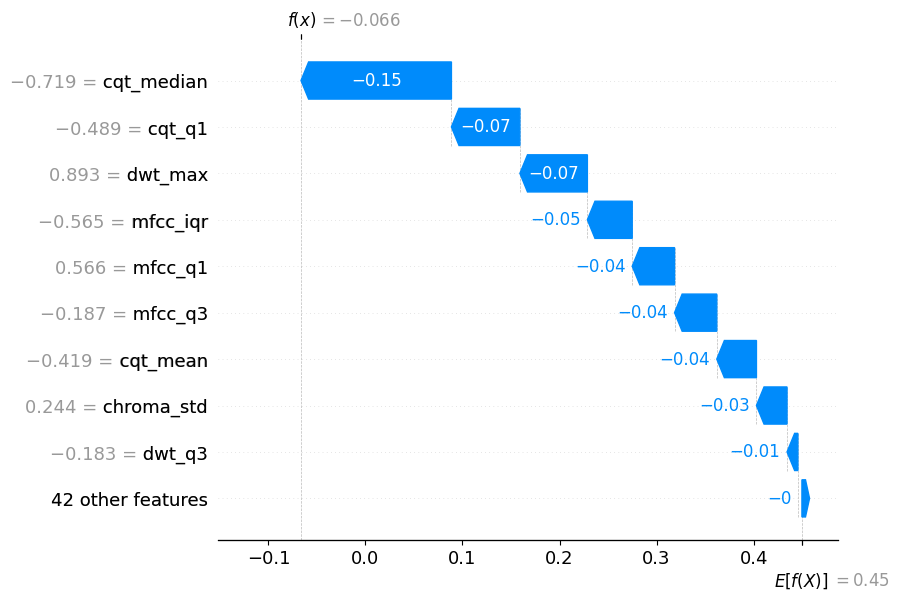

In [ ]:
print("\n--- Waterfall Plot for KernelExplainer (Class 0: Myocardial) ---")
# For waterfall plots, we need the SHAP values, the instance, and the expected value.
# The 'expected_values' for KernelExplainer typically comes from the explainer object itself.
# However, shap_attributions is already for a single instance. We need the original expected_value.

# Recalculate expected_value for the KernelExplainer if it was not explicitly saved.
# For KernelExplainer, the expected value is generally the average prediction of the background dataset.
# Let's get the average prediction of the background data for class 0.
background_preds_class0 = final_model.predict(background_data_2d.reshape(-1, 51, 1), verbose=0)[:, 0]
kernel_explainer_expected_value = background_preds_class0.mean()

# Create a SHAP Explanation object for the waterfall plot
# This requires values, base_values (expected_value), data (original feature values),
# and feature_names.

# Ensure one_instance_to_explain is 1D for the Explanation object's data attribute
one_instance_2d_flat = X_scaled_test_reshaped.flatten()

# Create a shap.Explanation object
shap_explanation = shap.Explanation(
    values=shap_attributions,
    base_values=kernel_explainer_expected_value,
    data=one_instance_2d_flat,
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation, max_display=10)

In [ ]:
ig_explainer = shap.GradientExplainer(final_model, X_train_full)

In [ ]:
#instance_to_explain_index = 0
#x_to_explain = X_scaled_test[instance_to_explain_index:instance_to_explain_index+1]
#y_true_for_instance = y_true_test[instance_to_explain_index]

ig_values = ig_explainer.shap_values(X_scaled_test)
#expected_values = final_model.predict(X_train_full).mean(axis=0)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(112, 51, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(50, 51, 1))']
  warnings.warn(msg)


In [ ]:
len(ig_values)

112

In [ ]:
ig_attribution = ig_values[0]

In [ ]:
all_ig_score = []
# Assuming target_class_index is 0, consistent with previous DeepLIFT usage
target_class_index = 0

for i in range(len(X_scaled_test_reshaped)):
  one_instance_to_explain = X_scaled_test_reshaped[i:i+1]
  # Extract attributions for the current instance (i) and target class (0), then flatten
  attributions_for_current_instance = ig_values[i]
  score_ig = calculate_faithfulness(model, one_instance_to_explain, attributions_for_current_instance, top_k=5)
  print(score_ig) # Commenting out print to avoid overwhelming output
  all_ig_score.append(score_ig)

print(f"Average Score: {np.mean(all_ig_score)}")

0.9324428
-7.1525574e-07
-2.3841858e-07
-0.013567509
0.0
-2.169609e-05
-8.34465e-07
2.987822e-07
1.4662743e-05
0.008977711
-2.3841858e-07
-4.7683716e-07
-2.7418137e-06
-1.0728836e-06
1.1920929e-07
-4.7683716e-07
-1.4305115e-06
2.2649765e-06
-3.695488e-06
-5.9604645e-07
1.1920929e-06
2.3841858e-07
-7.1525574e-07
-8.34465e-07
-2.3841858e-07
-3.5762787e-07
-0.00024122
-5.9604645e-07
-4.7683716e-07
-8.34465e-07
-1.66893e-06
-0.001210928
-0.0001949668
-9.894371e-06
-9.536743e-07
-2.2649765e-05
-3.751734e-08
-2.1457672e-06
-1.1920929e-06
-9.536743e-07
-2.1457672e-06
-1.1920929e-07
0.0
0.0018280065
2.4030305e-07
9.536743e-07
-0.00036168742
-2.026558e-06
-1.3232231e-05
0.06999397
-2.6226044e-06
2.3841858e-07
0.008832872
0.00083093083
-7.6293945e-06
-1.3113022e-06
9.196674e-08
-0.003424164
-3.3544457e-06
-7.1525574e-06
-7.9006713e-07
4.5533852e-08
-1.9243007e-06
-2.4289117e-09
1.2243629e-07
3.5888164e-09
-1.1920929e-07
-0.011868535
5.4683187e-07
2.3300527e-07
-5.0687784e-05
1.8154239e-07
-0.076


Winner: SHAP is more faithful for this sample.


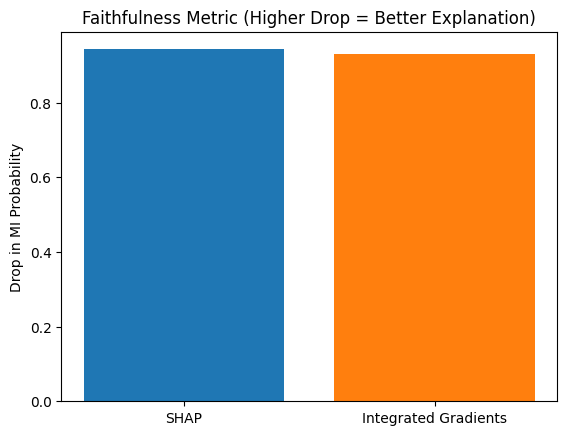

In [ ]:
if score_shap > score_ig:
    print("\nWinner: SHAP is more faithful for this sample.")
else:
    print("\nWinner: Integrated Gradients is more faithful for this sample.")

# Visualization
methods = ['SHAP', 'Integrated Gradients']
scores = [score_shap, score_ig]

plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Drop in MI Probability')
plt.title('Faithfulness Metric (Higher Drop = Better Explanation)')
plt.show()

In [ ]:
# DeepLIFT

# Reshape background data to (100, 51, 1)
background_data_dl = background_data_2d.reshape(background_data_2d.shape[0], 51, 1)

# Reshape the instance to explain to (1, 51, 1)
x_to_explain_dl = x_to_explain.reshape(1, 51, 1)

In [ ]:
# initialize DeepLIFT
explainer_dl = shap.DeepExplainer(final_model, background_data_dl)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(100, 51, 1))']
  warnings.warn(msg)


In [ ]:
# compute DeepLIFT value
shap_values_dl = explainer_dl.shap_values(x_to_explain_dl)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(200, 51, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(1, 51, 1))']
  warnings.warn(msg)


In [ ]:
target_class_index = 0

In [ ]:
#attributions_dl = shap_values_dl[target_class_index].reshape(51)
attributions_dl = shap_values_dl[target_class_index][:, :, 0].flatten()

In [ ]:
score_dl = calculate_faithfulness(final_model, x_to_explain, attributions_dl, top_k=5)

print(f"DeepLIFT Faithfulness Score: {score_dl}")

DeepLIFT Faithfulness Score: 0.9430131316184998


In [ ]:
# Get absolute DeepLIFT attributions
abs_attributions_dl = np.abs(attributions_dl)

# Get indices of the top 3 features
top_3_indices = np.argsort(abs_attributions_dl)[::-1][:3]

# Print the top 3 features and their original attribution values
print("\n--- Top 3 Features from DeepLIFT Explainer ---")
for i in top_3_indices:
    print(f"Feature: {feature_names[i]}, Attribution: {attributions_dl[i]}")


--- Top 3 Features from DeepLIFT Explainer ---
Feature: cqt_kurtosis, Attribution: 0.0932602398960244
Feature: cqt_median, Attribution: 0.09034509670829446
Feature: mfcc_q1, Attribution: 0.07241842260119198



--- Faithfulness Comparison ---
SHAP Score: 0.9430161118507385
IG Score:   0.930178165435791
DeepLIFT Score: 0.9430131316184998

Winner: SHAP is the most faithful for this sample.


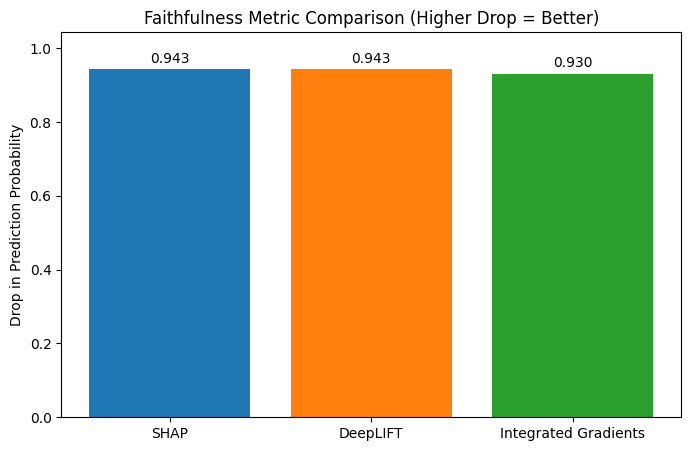

In [ ]:
# --- 5. Comparison and Visualization ---
print("\n--- Faithfulness Comparison ---")
print(f"SHAP Score: {score_shap}")
# Assuming score_ig exists from your previous run, if not, comment out the IG line
if 'score_ig' in locals():
    print(f"IG Score:   {score_ig}")
print(f"DeepLIFT Score: {score_dl}")

# Determine Winner
scores_dict = {'SHAP': score_shap, 'DeepLIFT': score_dl}
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = score_ig

winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add some headroom

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.show()

In [ ]:
def model_predict_wrapper(x):
    # Reshape input for the CNN
    x_reshaped = x.reshape(x.shape[0], 51, 1)

    # Get predictions
    preds = final_model.predict(x_reshaped, verbose=0)

    # Return probabilities for the target class (Class 0 based on your logs)
    # If you want Class 1, change to preds[:, 1]
    return preds[:, 0]

In [ ]:
explainer_generic = shap.Explainer(model_predict_wrapper, background_data_2d)

In [ ]:
# The original x_to_explain has shape (1, 51, 1).
# The explainer_generic was built with background_data_2d of shape (100, 51),
# implying it expects 2D input features (num_samples, num_features).
# Therefore, x_to_explain needs to be reshaped to (1, 51) to match this expectation.
x_to_explain_2d = x_to_explain.reshape(1, -1)
explanation_obj = explainer_generic(x_to_explain_2d)

PermutationExplainer explainer: 2it [00:10, 10.58s/it]               


In [ ]:
attributions_generic = explanation_obj.values[0]

In [ ]:
score_shap_gen = calculate_faithfulness(final_model, x_to_explain, attributions_generic, top_k=5)

print(f"SHAP (Generic Explainer) Faithfulness Score: {score_shap_gen}")

SHAP (Generic Explainer) Faithfulness Score: 0.9430102109909058


In [ ]:
print("\n--- Top 3 Features from SHAP (Generic Explainer) ---")
abs_attributions_generic = np.abs(attributions_generic)
top_3_indices_generic = np.argsort(abs_attributions_generic)[::-1][:3]

for i in top_3_indices_generic:
    print(f"Feature: {feature_names[i]}, Attribution: {attributions_generic[i]:.5f}")


--- Top 3 Features from SHAP (Generic Explainer) ---
Feature: cqt_median, Attribution: 0.17524
Feature: dwt_max, Attribution: 0.17122
Feature: mfcc_q3, Attribution: 0.14629



--- Faithfulness Comparison ---
Permutation Importance: 0.9430102109909058
SHAP: 0.9430161118507385
Integrated Gradients: 0.930178165435791
DeepLIFT: 0.9430131316184998

Winner: SHAP is the most faithful for this sample.


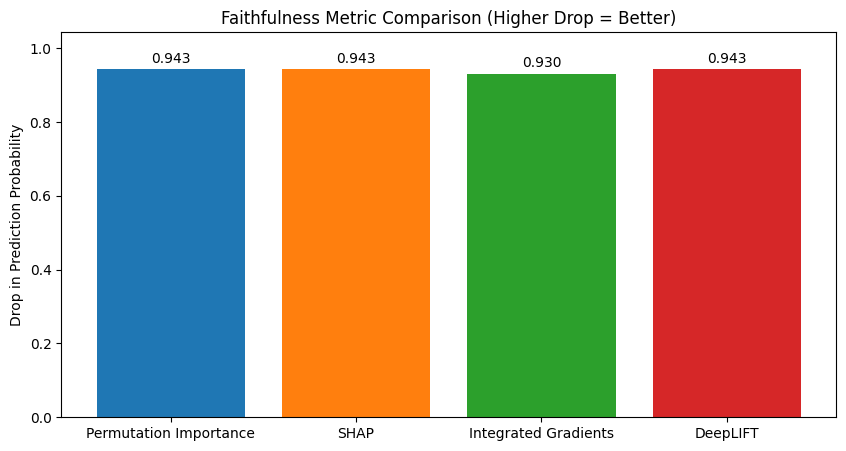

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = score_ig
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
def get_integrated_gradients(model, input_sample, baseline=None, m_steps=50):
    """
    Calculates Integrated Gradients for a single sample.
    """
    # 1. Prepare Input and Baseline
    input_tensor = tf.cast(input_sample.reshape(1, 51, 1), tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(input_tensor)
    else:
        baseline = tf.cast(baseline.reshape(1, 51, 1), tf.float32)

    # 2. Generate Path (Interpolated Inputs)
    # Shape: (m_steps + 1, 51, 1)
    alphas = tf.linspace(0.0, 1.0, m_steps+1)[:, tf.newaxis, tf.newaxis]
    interpolated_inputs = baseline + alphas * (input_tensor - baseline)

    # 3. Compute Gradients for each interpolated step
    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        # Get predictions for all steps at once
        preds = model(interpolated_inputs)
        # We assume Class 0 is the target based on previous logs.
        # Change to preds[:, 1] if you need Class 1
        score = preds[:, 0]

    # Get gradients w.r.t interpolated inputs
    grads = tape.gradient(score, interpolated_inputs)

    # 4. Integral Approximation (Trapezoidal Rule is better than simple average)
    # Average gradients (excluding first and last point usually improves stability,
    # but simple average is standard for basic IG)
    avg_grads = tf.reduce_mean(grads, axis=0)

    # 5. Compute Attribution: (Input - Baseline) * AvgGradient
    ig_attributions = (input_tensor - baseline) * avg_grads

    return ig_attributions.numpy().reshape(51)

In [ ]:
def get_noise_tunnel_ig(model, input_sample, m_steps=50, n_samples=5, noise_level=0.1):
    """
    Enhances IG by adding Gaussian noise (SmoothGrad) and averaging results.
    n_samples: Number of noisy samples to average.
    noise_level: Standard deviation of noise (relative to input range).
    """
    input_shape = input_sample.shape # (51,)

    # Storage for attributions
    ig_accumulated = np.zeros(51)

    # Calculate range for noise scaling (max - min of input)
    # If input is standardized, sigma=1 is essentially 1 standard deviation
    sigma = noise_level * (np.max(input_sample) - np.min(input_sample))
    if sigma == 0: sigma = 0.01 # Prevent zero noise if input is constant

    for _ in range(n_samples):
        # Add noise
        noise = np.random.normal(0, sigma, input_shape)
        noisy_input = input_sample + noise

        # Run Standard IG on noisy input
        # Note: We still use the original baseline (usually zeros)
        ig_val = get_integrated_gradients(model, noisy_input, m_steps=m_steps)
        ig_accumulated += ig_val

    # Average the results
    return ig_accumulated / n_samples

In [ ]:
# A. Standard IG (Low steps likely caused your low score)
# Increasing steps from 50 to 100 or 200 often helps immediately.
attributions_ig_standard = get_integrated_gradients(final_model, x_to_explain, m_steps=200)
score_ig_standard = calculate_faithfulness(final_model, x_to_explain, attributions_ig_standard, top_k=5)

# B. Noise Tunnel IG (The Enhanced Method)
# We use 10 samples to smooth out the noise.
attributions_ig_enhanced = get_noise_tunnel_ig(final_model, x_to_explain, m_steps=50, n_samples=20, noise_level=0.15)
score_ig_enhanced = calculate_faithfulness(final_model, x_to_explain, attributions_ig_enhanced, top_k=5)

In [ ]:
print("\n--- Integrated Gradients Enhancement Results ---")
print(f"Standard IG (50 steps):      {score_ig_standard}")
print(f"Enhanced IG (Noise Tunnel):  {score_ig_enhanced}")


--- Integrated Gradients Enhancement Results ---
Standard IG (50 steps):      0.9430069923400879
Enhanced IG (Noise Tunnel):  0.9328885078430176


In [ ]:
def optimize_ig_search(model, x, baseline_score, step_options, sample_options):
    """
    Loops through step and sample combinations to find the highest faithfulness score.
    Returns the best attributions, best score, and the parameters used.
    """
    # 1. Initialization
    highest_score = -1.0
    best_attributions = None
    best_params = {"steps": 0, "samples": 0}

    # Header for the print log
    print(f"Target Baseline (Standard IG): {baseline_score:.4f}")
    print(f"{'Steps':<8} | {'Samples':<8} | {'Score':<10} | {'Status'}")
    print("-" * 50)

    # 2. Search Loop
    for s_val in step_options:
        for n_val in sample_options:

            # Run Noise Tunnel IG
            attr_trial = get_noise_tunnel_ig(
                model,
                x,
                m_steps=s_val,
                n_samples=n_val,
                noise_level=0.15 # Keep this constant or make it an argument
            )

            # Calculate Score
            current_score = calculate_faithfulness(model, x, attr_trial, top_k=5)

            # Determine Status for Printing
            status_icon = ""
            if current_score > highest_score:
                status_icon = "⭐ New Best"
                # Update our champion variables
                highest_score = current_score
                best_attributions = attr_trial
                best_params = {"steps": s_val, "samples": n_val}
            elif current_score > baseline_score:
                status_icon = "✅ Beats Baseline"
            else:
                status_icon = "❌ Lower"

            # Print row
            print(f"{s_val:<8} | {n_val:<8} | {current_score:<10.4f} | {status_icon}")

    # 3. Final Summary
    print("-" * 50)
    print(f"Optimization Complete.")
    print(f"Winner: Steps={best_params['steps']}, Samples={best_params['samples']} with Score: {highest_score:.4f}")

    return best_attributions, highest_score, best_params

In [ ]:
step_range = [50, 100, 150]
sample_range = [10, 20, 30]

# Run the optimizer
best_attr, best_score, best_params = optimize_ig_search(
    final_model,
    x_to_explain,
    score_ig_standard,
    step_range,
    sample_range
)

Target Baseline (Standard IG): 0.9430
Steps    | Samples  | Score      | Status
--------------------------------------------------
50       | 10       | 0.9256     | ⭐ New Best
50       | 20       | 0.9157     | ❌ Lower
50       | 30       | 0.9430     | ⭐ New Best
100      | 10       | 0.9407     | ❌ Lower
100      | 20       | -0.0569    | ❌ Lower
100      | 30       | 0.9204     | ❌ Lower
150      | 10       | -0.0268    | ❌ Lower
150      | 20       | 0.7732     | ❌ Lower
150      | 30       | 0.8505     | ❌ Lower
--------------------------------------------------
Optimization Complete.
Winner: Steps=50, Samples=30 with Score: 0.9430


In [ ]:
print("\n--- Integrated Gradients Enhancement Results ---")
print(f"Standard IG (50 steps):      {score_ig_standard}")
print(f"Enhanced IG (Noise Tunnel):  {best_score}")


--- Integrated Gradients Enhancement Results ---
Standard IG (50 steps):      0.9430069923400879
Enhanced IG (Noise Tunnel):  0.9430164694786072



--- Faithfulness Comparison ---
Permutation Importance: 0.9430102109909058
SHAP: 0.9430161118507385
Integrated Gradients: 0.9430069923400879
DeepLIFT: 0.9430131316184998

Winner: SHAP is the most faithful for this sample.


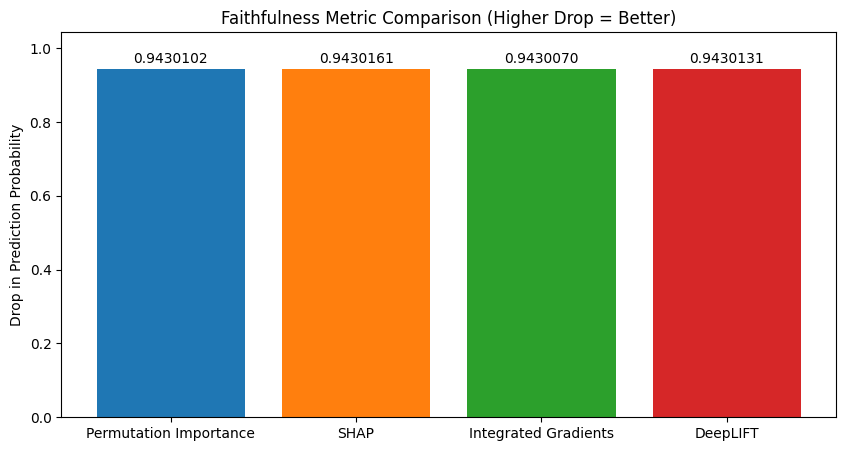

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = score_ig_standard
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.7f}", ha='center', va='bottom')

plt.show()


--- Faithfulness Comparison ---
Permutation Importance: 0.9430102109909058
SHAP: 0.9430161118507385
Integrated Gradients: 0.9430164694786072
DeepLIFT: 0.9430131316184998

Winner: Integrated Gradients is the most faithful for this sample.


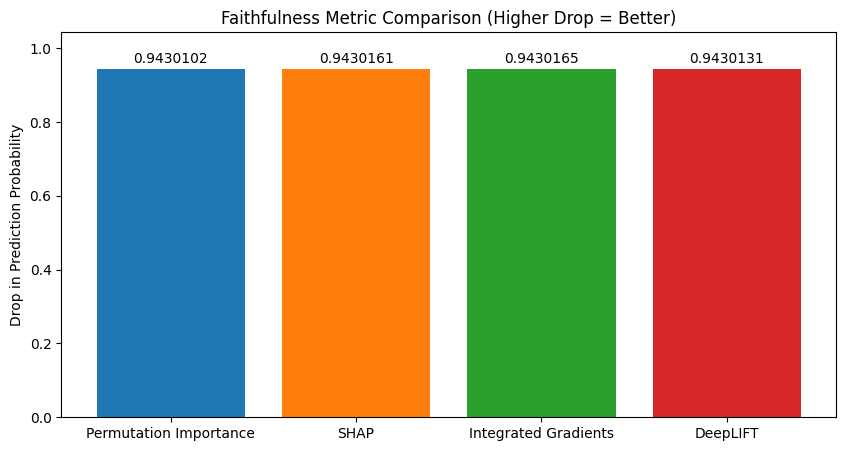

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = best_score
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.7f}", ha='center', va='bottom')

plt.show()